In [1]:
import cospar as cs
import pandas as pd
import scipy
import numpy as np
import os
import scanpy as sc
from cospar.plotting import _utils as pl_util

%reload_ext autoreload
%autoreload 2

import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
adata = sc.read_h5ad('../datasets/Mouse_Hematopoiesis/adata_used.h5ad')
adata.obs['Clone_ID'] = [name[6:] for name in adata.obs.clones.values]
adata

AnnData object with n_obs × n_vars = 44756 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones', 'Clone_ID'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [3]:
adata.obs

,Time_point,Population,Annotation,Well,time_cat,leiden,comb,label_man,clones,meta_clones,Clone_ID
0,6.0,LK,undiff,2,6.0,16,undiff_16,prog_2,Clone_573,8,573
1,6.0,LK,undiff,2,6.0,10,undiff_10,prog_Baso_Meg_Ery_Mast,Clone_1440,8,1440
2,6.0,LK,Monocyte,2,6.0,3,Monocyte_3,prog_Mono,Clone_394,0,394
4,6.0,LK,undiff,2,6.0,9,undiff_9,prog_Meg_Ery,Clone_1972,4,1972
6,6.0,LK,Neutrophil,2,6.0,7,Neutrophil_7,prog_Neu,Clone_1450,3,1450
...,...,...,...,...,...,...,...,...,...,...,...
130875,6.0,LSK,undiff,1,6.0,9,undiff_9,prog_Meg_Ery,Clone_12,4,12
130876,6.0,LSK,undiff,1,6.0,0,undiff_0,prog_2,Clone_267,8,267
130877,6.0,LSK,Neutrophil,1,6.0,1,Neutrophil_1,early_prog_Neu,Clone_3534,1,3534
130879,6.0,LSK,Monocyte,1,6.0,13,Monocyte_13,prog_Mono,Clone_4945,0,4945


In [4]:
selected_fates = ["Ery", "Meg", "Eos", "Mast", "DC", "Mono", "Neu", "pDC", "Ly", 'Baso']

In [5]:
import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/clonaltrans/')

path = '../trials/v1.2.0/checkpoints/WeinrebDynamicRates/1213_164212/model_last.pt'
model = torch.load(path, map_location='cpu')
device = torch.device('cpu')

import os 
os.chdir('/ssd/users/mingzegao/clonaltrans/')

In [16]:
anno = pd.read_csv(os.path.join(model.config['data_loader']['args']['data_dir'], model.config['data_loader']['args']['annots']))
cluster_names = anno['populations'].values[:model.N.shape[2]]

gillespie_dir='./trials/v1.2.0/checkpoints/WeinrebDynamicGillespie/1216_150917/models/'

In [16]:
from clonaltrans.pl import get_fate_prob, get_transit_path

aggre = get_fate_prob(model, cluster_names, gillespie_dir)
transit_paths, transit_paths_all = get_transit_path(model, cluster_names, 'prog_Baso_Meg_Ery_Mast', 'Ery', selected_fates)

array([0.35200585, 0.        , 0.20975126, 0.28528579, 1.        ,
       0.04209946, 0.08419893, 0.        , 0.00913918, 0.        ])

In [17]:
transit_paths

[['prog_Baso_Meg_Ery_Mast', 'prog_Meg_Ery', 'Ery']]

In [7]:
from clonaltrans.pl import compare_gt_pairwise

Init celltype: ['prog_2'], processed Clone 0 with 564 trails
Init celltype: ['prog_2'], processed Clone 1 with 527 trails
Init celltype: ['prog_2'], processed Clone 2 with 391 trails
Init celltype: ['prog_2'], processed Clone 3 with 786 trails
Init celltype: ['prog_2'], processed Clone 4 with 189 trails
Init celltype: ['prog_2'], processed Clone 5 with 273 trails
Init celltype: ['prog_2'], processed Clone 6 with 609 trails
Init celltype: ['prog_2'], processed Clone 7 with 545 trails
Init celltype: ['prog_2'], processed Clone 8 with 223 trails
Init celltype: ['prog_2'], processed Clone 9 with 144 trails
Init celltype: ['prog_2'], processed Clone 10 with 40 trails
Init celltype: ['prog_2'], processed Clone BG with 479 trails
Descendents of prog_2: ['Baso', 'DC', 'Eos', 'Ery', 'Ly', 'Mast', 'Meg', 'Mono', 'Neu', 'early_prog_Neu', 'pDC', 'prog_3', 'prog_4', 'prog_Baso_Eos', 'prog_Baso_Meg_Ery_Mast', 'prog_DC_Mono', 'prog_Ly_pDC', 'prog_Meg_Ery', 'prog_Mono', 'prog_Neu']


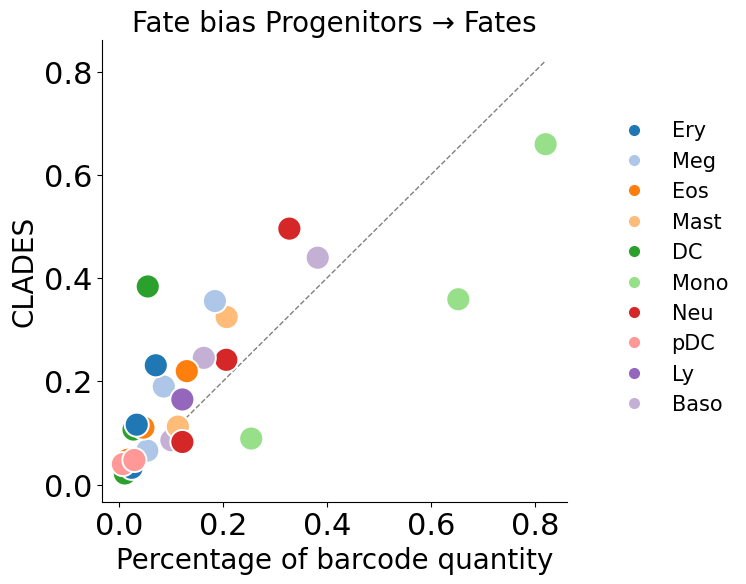

In [17]:
from clonaltrans.pl import compare_gt_all
compare_gt_all(
    adata, 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates,
    selected_fates,
    init_celltype=['prog_2'],
    show_fate=True,
    save='bias_all_fate'
)

Init celltype: ['prog_2'], processed Clone 0 with 564 trails
Init celltype: ['prog_2'], processed Clone 1 with 527 trails
Init celltype: ['prog_2'], processed Clone 2 with 391 trails
Init celltype: ['prog_2'], processed Clone 3 with 786 trails
Init celltype: ['prog_2'], processed Clone 4 with 189 trails
Init celltype: ['prog_2'], processed Clone 5 with 273 trails
Init celltype: ['prog_2'], processed Clone 6 with 609 trails
Init celltype: ['prog_2'], processed Clone 7 with 545 trails
Init celltype: ['prog_2'], processed Clone 8 with 223 trails
Init celltype: ['prog_2'], processed Clone 9 with 144 trails
Init celltype: ['prog_2'], processed Clone 10 with 40 trails
Init celltype: ['prog_2'], processed Clone BG with 479 trails
Descendents of prog_2: ['Baso', 'DC', 'Eos', 'Ery', 'Ly', 'Mast', 'Meg', 'Mono', 'Neu', 'early_prog_Neu', 'pDC', 'prog_3', 'prog_4', 'prog_Baso_Eos', 'prog_Baso_Meg_Ery_Mast', 'prog_DC_Mono', 'prog_Ly_pDC', 'prog_Meg_Ery', 'prog_Mono', 'prog_Neu']


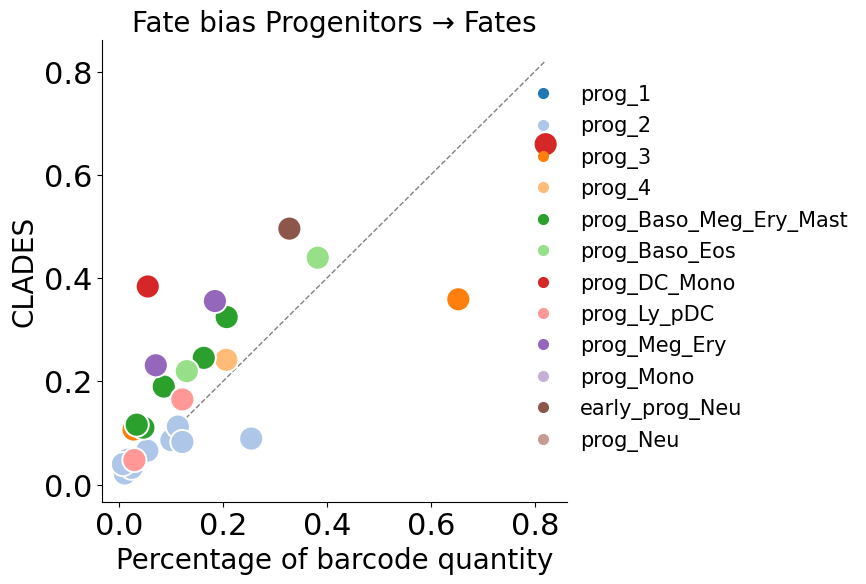

In [19]:
from clonaltrans.pl import compare_gt_all
compare_gt_all( 
    adata, 
    model, 
    cluster_names,
    gillespie_dir,
    selected_fates,
    selected_fates,
    init_celltype=['prog_2'],
    show_fate=False,
    save='bias_all_prog'
)

Init celltype: ['prog_1'], processed Clone 0 with 129 trails
Init celltype: ['prog_1'], processed Clone 1 with 349 trails
Init celltype: ['prog_1'], processed Clone 2 with 109 trails
Init celltype: ['prog_1'], processed Clone 3 with 7 trails
Init celltype: ['prog_1'], processed Clone 4 with 135 trails
Init celltype: ['prog_1'], processed Clone 5 with 524 trails
Init celltype: ['prog_1'], processed Clone 6 with 279 trails
Init celltype: ['prog_1'], processed Clone 7 with 12 trails
Init celltype: ['prog_1'], processed Clone 8 with 705 trails
Init celltype: ['prog_1'], processed Clone 9 with 41 trails
Init celltype: ['prog_1'], processed Clone 10 with 110 trails
Init celltype: ['prog_1'], processed Clone BG with 179 trails
[0.15408468 0.01130926 0.         0.18028169 0.11135802 0.00131614
 0.29468423 0.         0.         0.         0.         0.60638787]
[0.07038123 0.13606557 0.0455408  0.83794466 0.00733496 0.
 0.08650519 0.12056738 0.         0.         0.         0.15234931]


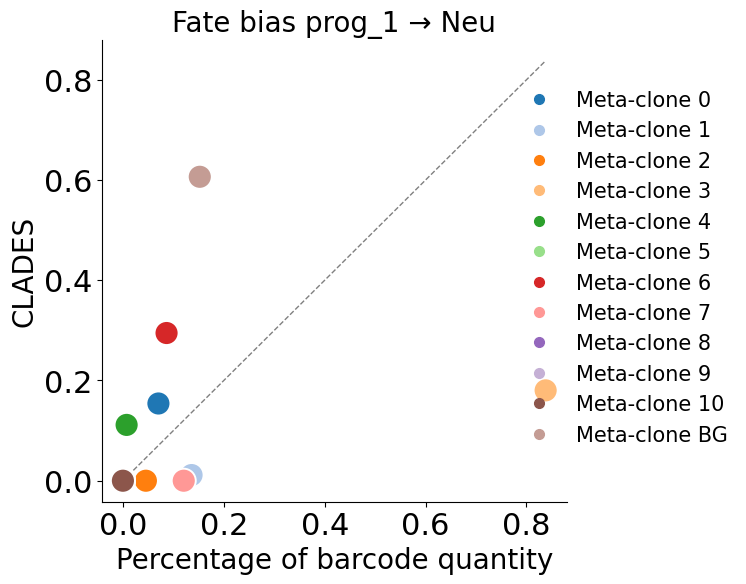

In [32]:
compare_gt_pairwise( 
    adata, 
    'prog_1', 
    'Neu', 
    model, 
    cluster_names,
    gillespie_dir, 
    selected_fates,
    init_celltype=['prog_1'],
    save='bias_prog2_Neu'
)

Init celltype: ['prog_1'], processed Clone 0 with 129 trails
Init celltype: ['prog_1'], processed Clone 1 with 349 trails
Init celltype: ['prog_1'], processed Clone 2 with 109 trails
Init celltype: ['prog_1'], processed Clone 3 with 7 trails
Init celltype: ['prog_1'], processed Clone 4 with 135 trails
Init celltype: ['prog_1'], processed Clone 5 with 524 trails
Init celltype: ['prog_1'], processed Clone 6 with 279 trails
Init celltype: ['prog_1'], processed Clone 7 with 12 trails
Init celltype: ['prog_1'], processed Clone 8 with 705 trails
Init celltype: ['prog_1'], processed Clone 9 with 41 trails
Init celltype: ['prog_1'], processed Clone 10 with 110 trails
Init celltype: ['prog_1'], processed Clone BG with 179 trails
[0.05581395 0.         0.00648689 0.         0.20671296 0.
 0.         0.         0.         0.         0.04817001 0.39774244]
[0.00146628 0.         0.0170778  0.00395257 0.19070905 0.
 0.         0.         0.         0.         0.05357143 0.02278121]


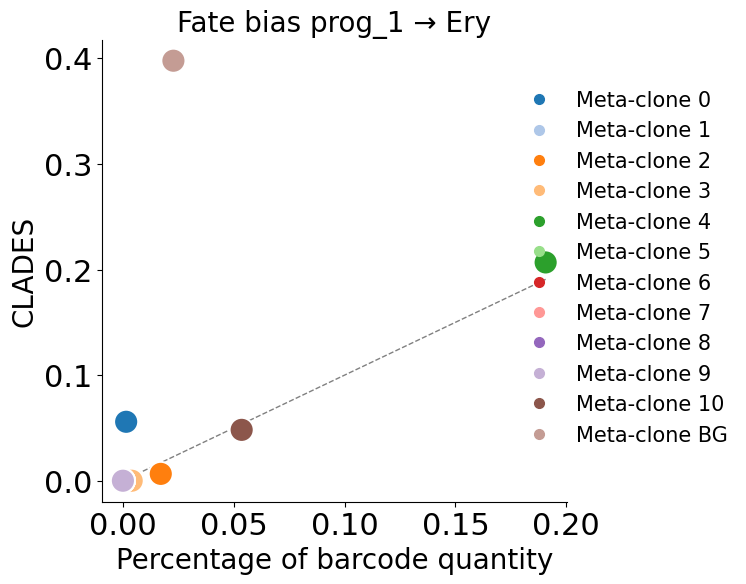

In [33]:
compare_gt_pairwise( 
    adata, 
    'prog_1', 
    'Ery', 
    model, 
    cluster_names,
    gillespie_dir, 
    selected_fates,
    init_celltype=['prog_1'],
    save='bias_prog2_Ery'
)